In [1]:
import mesa_reader as mr
import numpy as np

import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams['font.size'] = 12
from matplotlib.colors import LogNorm
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [2]:
# read in simulated masses
masses = np.loadtxt("models/masses.txt")

# specify variables for plotting for each mass
colors = plt.cm.viridis(np.linspace(0, 1, len(masses)))

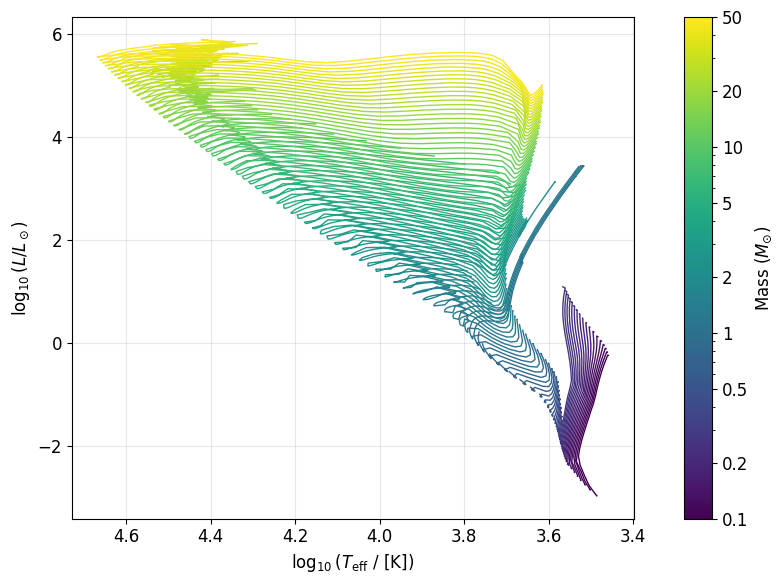

In [3]:
fig, ax = plt.subplots(figsize=(8, 6))
# iterate through masses and plot log L vs log T_eff
for i, mass in enumerate(masses):
    # get directory name for current mass
    mass_str = f"{mass:.4f}"
    dir = f"models/{mass_str}/LOGS"

    # read in history
    logs = mr.MesaLogDir(dir)
    history = logs.history

    # plot HR path
    plt.plot(history.log_Teff, history.log_L, color=colors[i], lw=1)

# create colorbar
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.5)
cbar = mpl.colorbar.ColorbarBase(cax, cmap='viridis', norm=LogNorm(vmin=0.1, vmax=50), orientation='vertical')
cbar.set_label(r'Mass ($M_{\odot}$)')
cbar.set_ticks([0.1, 0.2, 0.5, 1, 2, 5, 10, 20, 50])
cbar.set_ticklabels(['0.1', '0.2', '0.5', '1', '2', '5', '10', '20', '50'])

# make plot spiffy and save
ax.set_xlabel(r"$\log_{10}(T_{\mathrm{eff}}\ /\ \mathrm{[K]})$")
ax.set_ylabel(r"$\log_{10}(L / L_\odot)$")
ax.invert_xaxis()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"plots/total_HR.png")

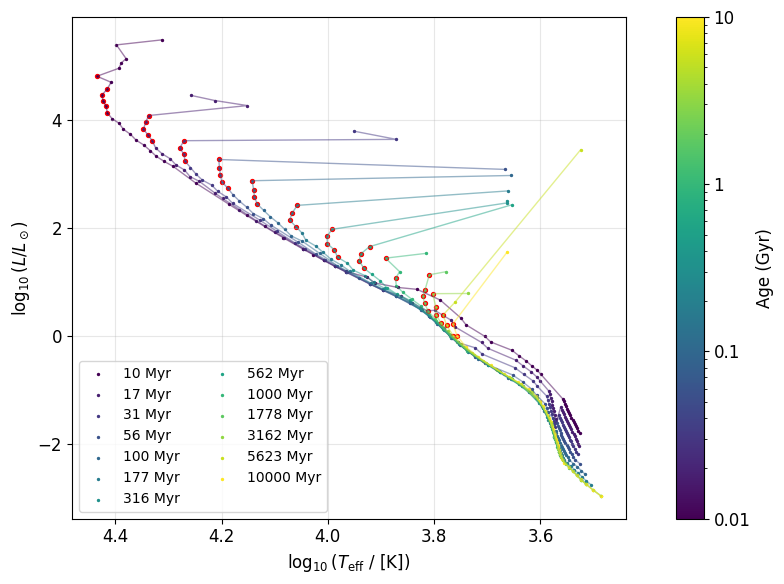

In [7]:
# plot isochrones at the following times
isoc_times = 10**np.linspace(7., 10., 13, endpoint=True)  # in years
log_times = np.log10(isoc_times)
isoc_data = {isoc_time: {"time_errs": [], "masses": [], "log_T_effs": [], "log_Ls": [], "MS_turnoff_inds": []} for isoc_time in isoc_times}

fig, ax = plt.subplots(figsize=(8, 6))
# iterate through isochrone times and gather points for all valid stars
for i, isoc_time in enumerate(isoc_times):
    isoc_time_half_range = 0.20 * isoc_time  # 20% error allotted to determine whether star is on this isochrone
    isoc_time_errs = []  # track the actual time errors for each star for uncertainty estimation
    isoc_masses = []
    isoc_log_T_effs = []
    isoc_log_Ls = []
    for mass in masses:
        # get directory name for current mass
        mass_str = f"{mass:.4f}"
        dir = f"models/{mass_str}/LOGS"

        # read in history
        logs = mr.MesaLogDir(dir)
        history = logs.history

        # find closest time to isochrone time
        closest_time = np.min(np.abs(history.star_age - isoc_time)) 
        
        # if closest time within isochrone time error, add point to isochrone
        if closest_time <= isoc_time_half_range:
            closest_ind = np.argmin(np.abs(history.star_age - isoc_time))
            isoc_time_errs.append(closest_time)
            isoc_masses.append(mass)
            isoc_log_T_effs.append(history.log_Teff[closest_ind])
            isoc_log_Ls.append(history.log_L[closest_ind])

    if not isoc_masses:  # no stars fit this isochrone time
        continue

    # estimate the index of the MS turnoff point using the highest Teff points on the isochrone
    # begin with the highest Teff point, and average over any points within 0.02 dex (~5%)
    max_log_T_eff = np.max(isoc_log_T_effs)
    MS_turnoff_inds = np.where(np.abs(isoc_log_T_effs - max_log_T_eff) <= 0.02)[0]

    # log isochrone data for this time
    isoc_data[isoc_time]["time_errs"] = np.copy(isoc_time_errs)
    isoc_data[isoc_time]["masses"] = np.copy(isoc_masses)
    isoc_data[isoc_time]["log_T_effs"] = np.copy(isoc_log_T_effs)
    isoc_data[isoc_time]["log_Ls"] = np.copy(isoc_log_Ls)
    isoc_data[isoc_time]["MS_turnoff_inds"] = np.copy(MS_turnoff_inds)
        
    # plot isochrone points for this time
    color_val = i / (len(isoc_times) - 1)
    plt.plot(isoc_log_T_effs, isoc_log_Ls, color=plt.cm.viridis(color_val), lw = 1, alpha=0.5)
    plt.scatter(isoc_log_T_effs, isoc_log_Ls, color=plt.cm.viridis(color_val), s=2, label=f"{int(isoc_time/1.e6)} Myr")

    # highlight MS turnoff points in red
    plt.scatter(np.array(isoc_log_T_effs)[MS_turnoff_inds], np.array(isoc_log_Ls)[MS_turnoff_inds], marker='o', facecolors=plt.cm.viridis(color_val), edgecolors='red', s=8)

# create colorbar
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.5)
cbar = mpl.colorbar.ColorbarBase(cax, cmap='viridis', norm=LogNorm(vmin=0.01, vmax=10), orientation='vertical')
cbar.set_label(r'Age (Gyr)')
cbar.set_ticks([0.01, 0.1, 1, 10])
cbar.set_ticklabels(['0.01', '0.1', '1', '10'])

# make plot spiffy and save
ax.set_xlabel(r"$\log_{10}(T_{\mathrm{eff}}\ /\ \mathrm{[K]})$")
ax.set_ylabel(r"$\log_{10}(L / L_\odot)$")
ax.invert_xaxis()
ax.legend(ncol=2, fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"plots/isochrones_HR.png")

In [10]:
# compute (average) MS turnoff luminosity and mass for each isochrone time 
# also estimate uncertainties using standard deviations
MS_turnoff_masses = []
MS_turnoff_masses_uncs = []
MS_turnoff_log_Ls = []
MS_turnoff_log_Ls_uncs = []
MS_turnoff_t_uncs = []
for isoc_time in isoc_times:
    MS_turnoff_masses.append(np.mean((isoc_data[isoc_time]['masses'])[isoc_data[isoc_time]['MS_turnoff_inds']]))
    MS_turnoff_masses_uncs.append(np.std((isoc_data[isoc_time]['masses'])[isoc_data[isoc_time]['MS_turnoff_inds']]))
    MS_turnoff_log_Ls.append(np.mean((isoc_data[isoc_time]['log_Ls'])[isoc_data[isoc_time]['MS_turnoff_inds']]))
    MS_turnoff_log_Ls_uncs.append(np.std((isoc_data[isoc_time]['log_Ls'])[isoc_data[isoc_time]['MS_turnoff_inds']]))
    MS_turnoff_t_uncs.append(np.mean((isoc_data[isoc_time]['time_errs'])[isoc_data[isoc_time]['MS_turnoff_inds']]))
MS_turnoff_masses = np.array(MS_turnoff_masses)
MS_turnoff_masses_uncs = np.array(MS_turnoff_masses_uncs)
MS_turnoff_log_Ls = np.array(MS_turnoff_log_Ls)
MS_turnoff_log_Ls_uncs = np.array(MS_turnoff_log_Ls_uncs)
MS_turnoff_t_uncs = np.array(MS_turnoff_t_uncs)
MS_turnoff_t_log_uncs = (1 / np.log(10)) * np.abs(MS_turnoff_t_uncs / isoc_times)  # convert to log uncertainties for plotting

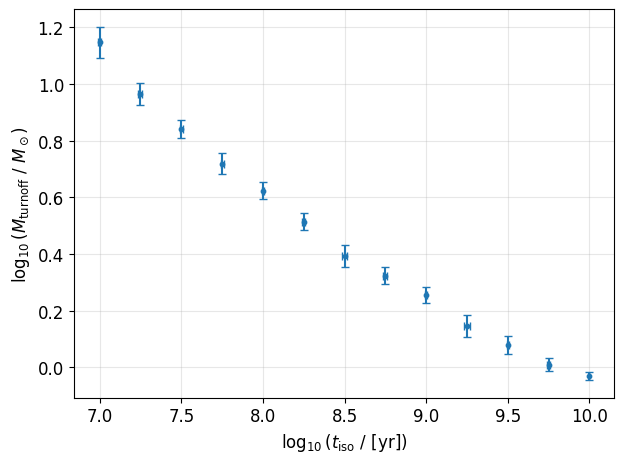

In [11]:
# plot masses vs times
plt.scatter(log_times, np.log10(MS_turnoff_masses), marker='o', s=10)
MS_turnoff_masses_log_uncs = (1 / np.log(10)) * np.abs(MS_turnoff_masses_uncs / MS_turnoff_masses)
plt.errorbar(log_times, np.log10(MS_turnoff_masses), yerr=MS_turnoff_masses_log_uncs, xerr=MS_turnoff_t_log_uncs, fmt='none', capsize=3)
# make plot spiffy and save
plt.xlabel(r"$\log_{10}(t_{\text{iso}}\ /\ [\mathrm{yr}])$")
plt.ylabel(r"$\log_{10}(M_{\text{turnoff}}\ /\ M_\odot)$")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"plots/logM_logt.png")

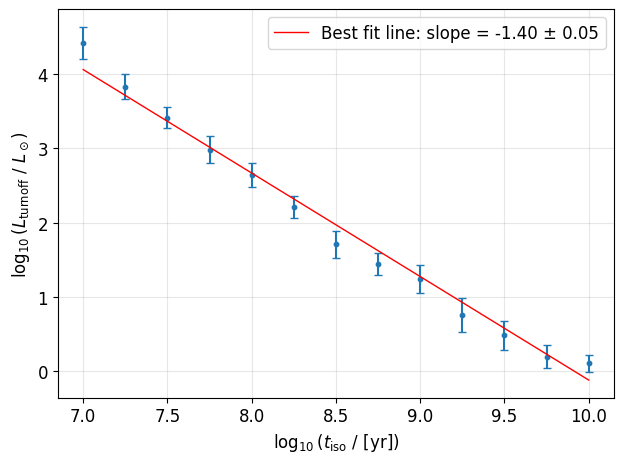

In [12]:
# fit a line to log L vs log time (ignore x errs)
coeffs, cov = np.polyfit(log_times, MS_turnoff_log_Ls, w = 1/MS_turnoff_log_Ls_uncs, deg=1, cov=True)

# plot turnoff luminosities vs times
plt.scatter(log_times, MS_turnoff_log_Ls, s=10)
plt.errorbar(log_times, MS_turnoff_log_Ls, yerr=MS_turnoff_log_Ls_uncs, fmt='none', capsize=3)
# plot best fit line
plt.plot(log_times, np.polyval(coeffs, log_times), color='red', lw=1, label=f"Best fit line: slope = {coeffs[0]:.2f} ± {np.sqrt(cov[0][0]):.2f}")
# make plot spiffy and save
plt.xlabel(r"$\log_{10}(t_{\text{iso}}\ /\ [\mathrm{yr}])$")
plt.ylabel(r"$\log_{10}(L_{\text{turnoff}}\ /\ L_\odot)$")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(f"plots/logL_logt.png")

In [16]:
### ESTIMATING AGE OF M3 ###
# estimate MS turnoff apparent magnitude from Pols Figure 1.2 
MS_turnoff_app_mag_M3 = 19
MS_turnoff_app_mag_M3_unc = 1.
# convert to absolute magnitude using distance modulus with distance to M3 of 10.4 kpc https://en.wikipedia.org/wiki/Messier_3
distance_M3_pc = 10400
MS_turnoff_abs_mag_M3 = MS_turnoff_app_mag_M3 - (100**0.2) * np.log10((distance_M3_pc / 10)**2)
MS_turnoff_abs_mag_M3_unc = MS_turnoff_app_mag_M3_unc  # ignore any distance uncertainty 
# convert to log luminosity using M_bol_sun = 4.74 https://arxiv.org/pdf/1510.06262
MS_turnoff_log_L_M3 = (1 / 100**0.2) * (4.74 - MS_turnoff_abs_mag_M3)
MS_turnoff_log_L_M3_unc = (1 / 100**0.2) * MS_turnoff_abs_mag_M3_unc

# use best fit line to estimate M3 age with uncertainty
log_t_M3 = (MS_turnoff_log_L_M3 - coeffs[1]) / coeffs[0]
# propagate uncertainty from log L measurement and fit coeffs including covariance using partials formula
# in this case for y = m*x + b we have sigma_x**2 = (1/m**2) * (sigma_y**2 + sigma_b**2 + x**2 * sigma_m**2 + 2*x*cov(m,b))
log_t_M3_var = (1. / coeffs[0]**2) * (MS_turnoff_log_L_M3_unc**2 + cov[1][1] + log_t_M3**2 * cov[0][0] + 2*log_t_M3*cov[0][1])
log_t_M3_unc = np.sqrt(log_t_M3_var)
# convert log time to years and print result
t_M3 = 10**log_t_M3
t_M3_unc = np.log(10) * t_M3 * log_t_M3_unc
print(f"Estimated age of M3: {t_M3/1e9:.2f} ± {t_M3_unc/1e9:.2f} Gyr")  

Estimated age of M3: 4.54 ± 3.03 Gyr
